# Actividad 2 - Procesamiento de imágenes aplicado a una imagen GPS

**Nombre: Karen Andrea Ingala Huaygua**  
**ID: 707.001.536-0**  
**Fecha:22/05/2026**  

En esta actividad se trabaja con una imagen tipo mapa que contiene una trayectoria GPS degradada. El objetivo es aplicar herramientas básicas de procesamiento de imágenes: visualización, histograma, filtrado, estimación/remoción de fondo y transformada wavelet 2D tipo Haar.

**Importante:** esta actividad no incluye análisis de series temporales, predicción lineal, clasificación ni métricas de detección de objetos. Es una actividad corta de preparación para el Proyecto II.

In [ ]:
# Importa aquí las librerías necesarias.

## 1. Leer un caso y visualizar la información disponible

Seleccione uno de los casos del conjunto de datos. Cargue y visualice:

- `map_background.png`,
- `gps_trace_clean.png`,
- `gps_trace_noisy.png`,
- `gps_trace_overlay.png`.

Explique brevemente qué información contiene cada imagen.

In [4]:
%pip install opencv-python numpy matplotlib

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


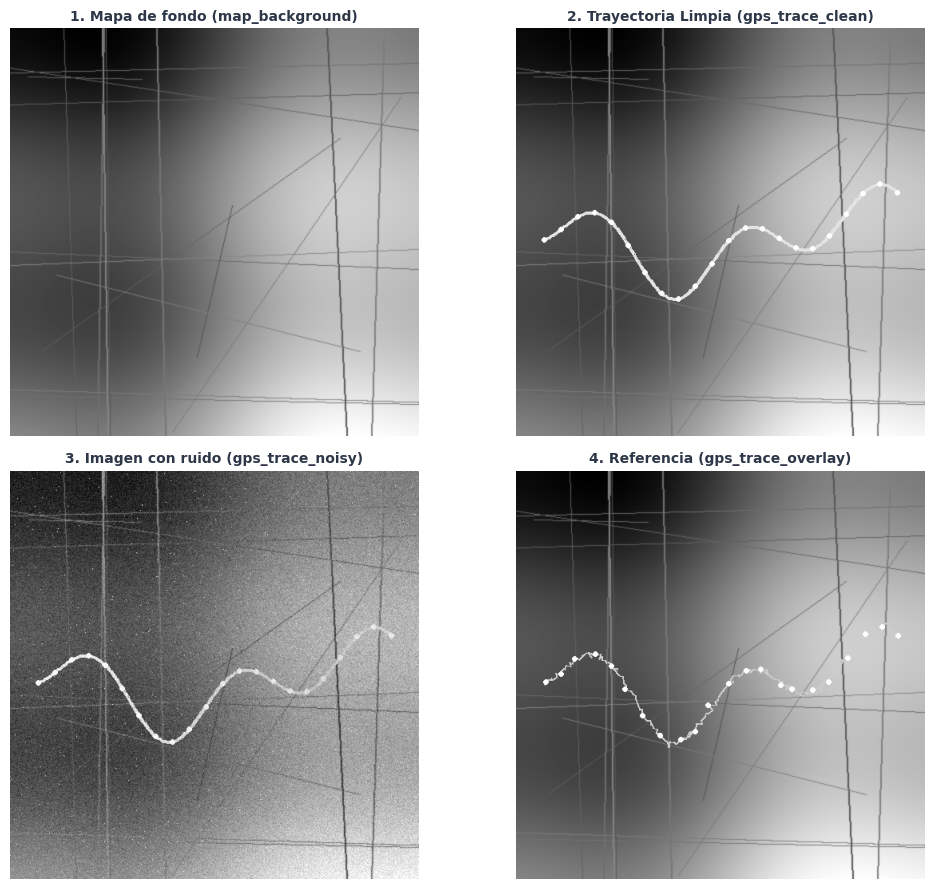

In [19]:
#Se hizo el analisis con el caso 004
import cv2
import numpy as np
import matplotlib.pyplot as plt

map_background = cv2.imread('map_background.png', cv2.IMREAD_GRAYSCALE)
gps_trace_clean = cv2.imread('gps_trace_clean.png', cv2.IMREAD_GRAYSCALE)
gps_trace_noisy = cv2.imread('gps_trace_noisy.png', cv2.IMREAD_GRAYSCALE)
gps_trace_overlay = cv2.imread('gps_trace_overlay.png', cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
images = [map_background, gps_trace_clean, gps_trace_noisy, gps_trace_overlay]
titles = [
    "1. Mapa de fondo (map_background)", 
    "2. Trayectoria Limpia (gps_trace_clean)",
    "3. Imagen con ruido (gps_trace_noisy)", 
    "4. Referencia (gps_trace_overlay)"
]

for ax, img, title in zip(axes.flatten(), images, titles):
    if img is not None:
        ax.imshow(img, cmap='gray')
    else:
        ax.text(0.5, 0.5, 'Archivo no encontrado', ha='center', va='center')
        
    ax.set_title(title, fontsize=10, fontweight='bold', color='#2d3748')
    ax.axis('off')

plt.tight_layout()
plt.show()

Análisis y descripción visual de las imágenes:

1. Mapa de Fondo: Visualmente se aprecia una imagen en tonos grises con degradados y varias líneas rectas delgadas que se cruzan en distintos ángulos. Representa el escenario base estático (como infraestructura o un plano geométrico) que operará como nuestro fondo.

2. Trayectoria Limpia: Se observa una línea blanca brillante y ondulada (formada por puntos conectados) que resalta sobre el fondo oscuro. Representa la ruta ideal y perfecta del dispositivo GPS, totalmente aislada y sin ninguna interferencia.

3. Imagen con Ruido: Se alcanza a ver la línea blanca ondulada y las líneas rectas de fondo, pero toda la imagen está cubierta por una capa densa de puntitos (un granulado). Esta es la señal de entrada real que vamos a procesar, la cual está corrompida por ruido que debemos limpiar.

4. Referencia: Es la combinación nítida de las primeras dos imágenes. Vemos el fondo gris con sus líneas rectas y, superpuesta a este, la línea blanca ondulada muy clara y definida, sin nada de estática. Funciona como nuestra "verdad de campo" o guía para saber a qué resultado exacto queremos llegar tras aplicar los filtros de limpieza.

## 2. Histograma de intensidad

Calcule y grafique el histograma de intensidad de `gps_trace_noisy.png`.

Discuta:

- qué rango de intensidades parece corresponder al fondo,
- qué rango podría corresponder a la trayectoria o a estructuras brillantes,
- por qué el histograma es útil antes de aplicar un umbral o una corrección de contraste.

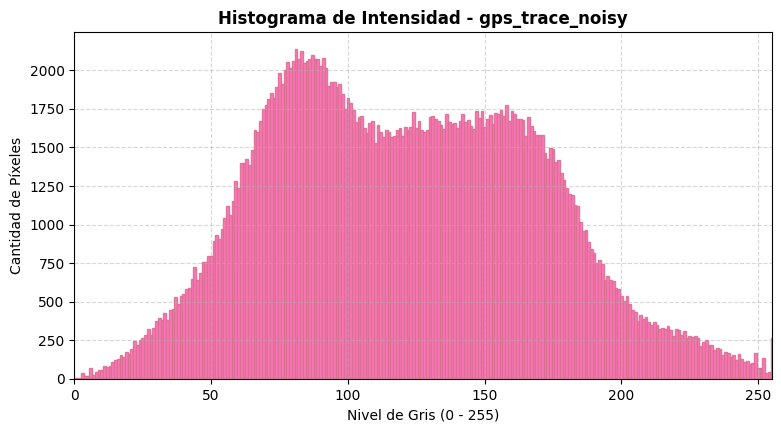

In [ ]:
# Calculamos el histograma usando la variable 'gps_trace_noisy'
hist_ruido = cv2.calcHist([gps_trace_noisy], [0], None, [256], [0, 256])

plt.figure(figsize=(9, 4.5))
plt.bar(range(256), hist_ruido.ravel(), color='hotpink', edgecolor='palevioletred', width=1, alpha=0.9)

plt.title('Histograma de Intensidad - gps_trace_noisy', fontweight='bold')
plt.xlabel('Nivel de Gris (0 - 255)')
plt.ylabel('Cantidad de Píxeles')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([0, 255])
plt.show()

Discusión del Histograma:

1. ¿Qué rango de intensidades parece corresponder al fondo?
El fondo ocupa la mayor parte del área de la imagen, por lo que corresponde a la gran masa principal del histograma. Este grupo mayoritario de píxeles se concentra en los niveles de grises bajos y medios, abarcando aproximadamente el rango de intensidades entre $0$ y $150$, donde observamos el cuerpo más ancho y alto de la gráfica.
2. ¿Qué rango podría corresponder a la trayectoria o a estructuras brillantes?
La trayectoria de la señal GPS destaca por ser muy brillante (blanca) sobre el fondo oscuro. En el histograma, esto se refleja en los niveles de intensidad más altos. Podemos ubicar la trayectoria en el rango superior, aproximadamente entre $180$ y $240$, formando las elevaciones menores que se extienden hacia el lado derecho del gráfico.
3. ¿Por qué el histograma es útil antes de aplicar un umbral o una corrección de contraste?
El histograma es una herramienta diagnóstica fundamental porque nos muestra si existe una separación clara entre el objeto de interés (la trayectoria) y el fondo. Al observar la gráfica, vemos que aunque hay dos zonas principales, los valores se solapan debido a la "estática" o ruido esparcido por toda la imagen (como se evidencia en los valores extremos de $0$ y $255$). Esto nos indica que aplicar un umbral directo (como binarizar) fracasaría, ya que el ruido brillante también se volvería blanco, arruinando la extracción de la ruta. El histograma nos justifica que es estrictamente necesario aplicar filtros espaciales para limpiar la imagen antes de intentar cualquier umbralizado.

## 3. Filtro gaussiano y filtro de mediana

Aplique un filtro gaussiano y un filtro de mediana a la imagen degradada.

Compare ambos resultados y explique:

- cuál reduce mejor el ruido suave,
- cuál es más efectivo frente a píxeles impulsivos,
- qué efectos no deseados pueden aparecer sobre bordes o estructuras delgadas.

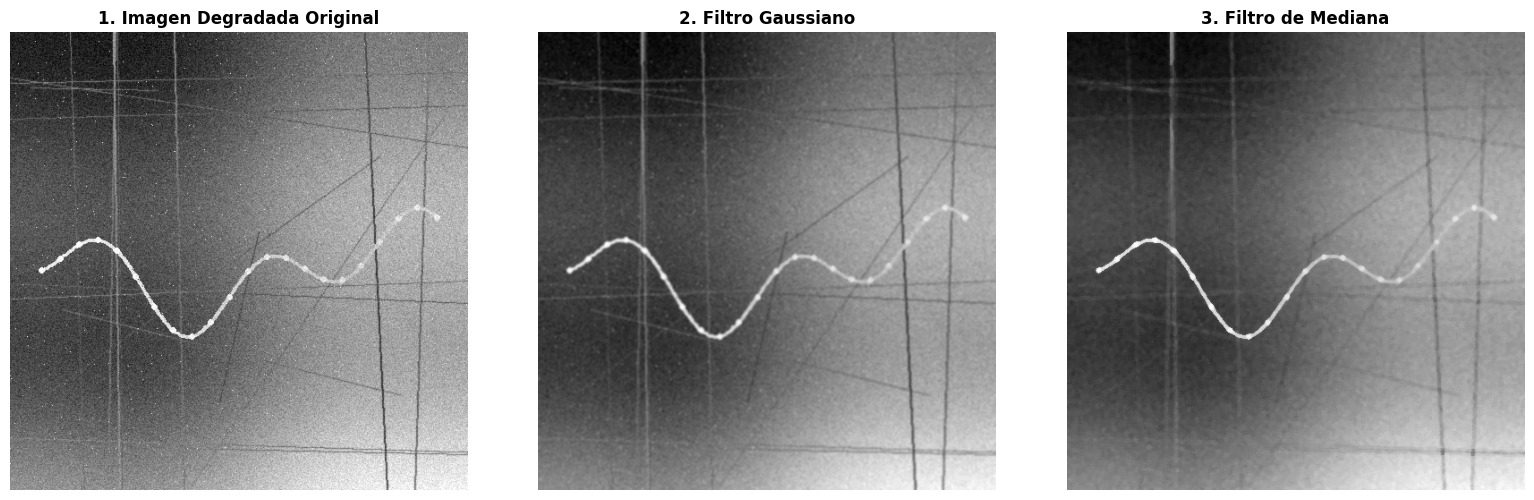

In [ ]:
# Filtro gaussiano y filtro de mediana
tamano_kernel = 5 # El tamaño de la ventana de análisis debe ser impar (5x5)

# Filtro Gaussiano (difumina promediando los píxeles vecinos)
filtro_gaussiano = cv2.GaussianBlur(gps_trace_noisy, (tamano_kernel, tamano_kernel), 0)

# Filtro de Mediana (reemplaza el píxel por el valor central de sus vecinos)
filtro_mediana = cv2.medianBlur(gps_trace_noisy, tamano_kernel)

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(gps_trace_noisy, cmap='gray')
axes[0].set_title('1. Imagen Degradada Original', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(filtro_gaussiano, cmap='gray')
axes[1].set_title('2. Filtro Gaussiano', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(filtro_mediana, cmap='gray')
axes[2].set_title('3. Filtro de Mediana', fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Comparación de Filtros:
1. ¿Cuál reduce mejor el ruido suave?
El Filtro Gaussiano. Al realizar un promedio ponderado de los píxeles vecinos, suaviza las transiciones continuas y es ideal para atenuar pequeñas variaciones de iluminación o ruido de fondo (ruido continuo o gaussiano).
2. ¿Cuál es más efectivo frente a píxeles impulsivos?
El Filtro de Mediana es abrumadoramente superior para el ruido impulsivo (la "estática" tipo sal y pimienta presente en la imagen). Como toma el valor estadístico central de la vecindad en lugar de promediarlos, elimina por completo los puntos extremos atípicos ($0$ y $255$) dejando la trayectoria impecable.
3. ¿Qué efectos no deseados pueden aparecer sobre bordes o estructuras delgadas?
- Con el Filtro Gaussiano, el principal problema es el efecto de desenfoque: los bordes de la trayectoria del GPS se difuminan, perdiendo nitidez y viéndose más gruesos.
- Con el Filtro de Mediana, si la estructura es demasiado delgada (más fina que el radio del filtro), el algoritmo puede interpretarla erróneamente como ruido atípico y borrar fragmentos de la ruta.

## 4. Estimación y remoción de fondo

Estime un fondo suave $B(x,y)$ usando un filtro de gran escala. Luego calcule

$$
I_{\mathrm{corr}}(x,y)=I(x,y)-B(x,y).
$$

Muestre la imagen original degradada, el fondo estimado y la imagen corregida.

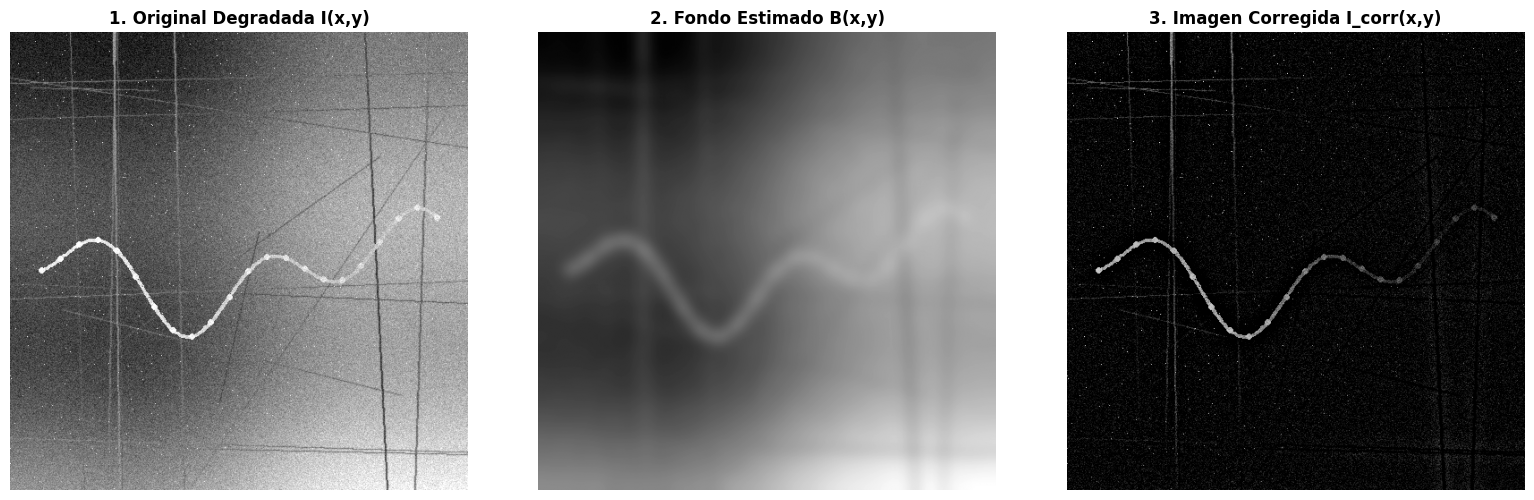

In [ ]:
# 4. Estimación y remoción de fondo

# Estimar el fondo suave B(x,y) usando un kernel gaussiano de gran escala
kernel_grande = 51  
fondo_estimado = cv2.GaussianBlur(gps_trace_noisy, (kernel_grande, kernel_grande), 0)

# Resta matemática: I_corr(x,y) = I(x,y) - B(x,y)
img_original_f = gps_trace_noisy.astype(np.float32)
fondo_estimado_f = fondo_estimado.astype(np.float32)

imagen_corregida_f = img_original_f - fondo_estimado_f

imagen_corregida = np.clip(imagen_corregida_f, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(gps_trace_noisy, cmap='gray')
axes[0].set_title("1. Original Degradada I(x,y)", fontweight='bold')
axes[0].axis('off')

axes[1].imshow(fondo_estimado, cmap='gray')
axes[1].set_title("2. Fondo Estimado B(x,y)", fontweight='bold')
axes[1].axis('off')

axes[2].imshow(imagen_corregida, cmap='gray')
axes[2].set_title("3. Imagen Corregida I_corr(x,y)", fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Análisis de la Remoción de Fondo:

Para aislar la trayectoria GPS del mapa urbano, estimamos el fondo $B(x, y)$ aplicando un Filtro Gaussiano con un tamaño de kernel muy grande ($51 \times 51$). Al hacer esto, las estructuras delgadas y de alta frecuencia (como la línea del GPS y la estática) se promedian con su entorno y desaparecen, dejándonos una imagen que contiene únicamente la iluminación base y las variaciones suaves del mapa.

Al restar matemáticamente este fondo estimado de la imagen original, logramos cancelar la interferencia del mapa, haciendo que la trayectoria y el ruido resalten de manera uniforme sobre un lienzo oscuro.

## 5. Transformada wavelet 2D tipo Haar

Implemente o aplique una transformada Haar 2D de un nivel para obtener las subbandas:

$$
I(x,y) \rightarrow \{LL,LH,HL,HH\}.
$$

Muestre las cuatro subbandas y reconstruya la imagen. Verifique visualmente que la reconstrucción sea consistente.

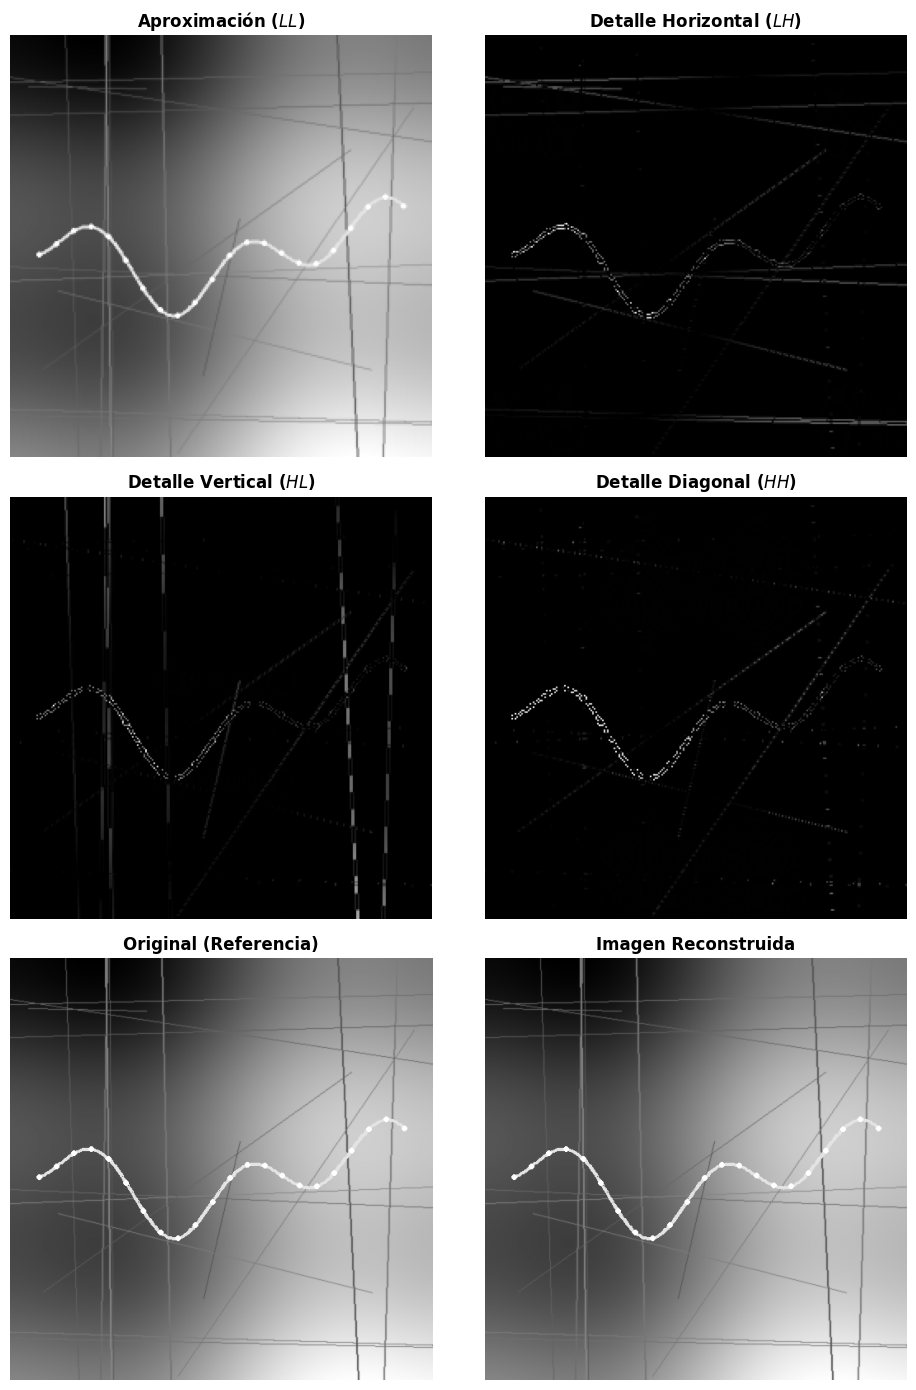

In [ ]:
# 5. Transformada wavelet 2D tipo Haar
# Implementación matricial para 1 nivel de descomposición

def transformada_haar_2d(imagen):
    img = imagen.astype(np.float32)
    h, w = img.shape
    h, w = (h // 2) * 2, (w // 2) * 2
    img = img[:h, :w]
    
    # Filtro horizontal (agrupamos por pares de columnas)
    promedio_cols = (img[:, 0::2] + img[:, 1::2]) / 2.0
    diferencia_cols = (img[:, 0::2] - img[:, 1::2]) / 2.0
    
    # Filtro vertical (agrupamos por pares de filas)
    LL = (promedio_cols[0::2, :] + promedio_cols[1::2, :]) / 2.0
    LH = (promedio_cols[0::2, :] - promedio_cols[1::2, :]) / 2.0
    HL = (diferencia_cols[0::2, :] + diferencia_cols[1::2, :]) / 2.0
    HH = (diferencia_cols[0::2, :] - diferencia_cols[1::2, :]) / 2.0
    
    return LL, LH, HL, HH

def reconstruccion_haar_2d(LL, LH, HL, HH):
    h_sub, w_sub = LL.shape
    h, w = h_sub * 2, w_sub * 2
    reconstruida = np.zeros((h, w), dtype=np.float32)
    
    # Reconstrucción inversa exacta sumando y restando las subbandas
    reconstruida[0::2, 0::2] = LL + LH + HL + HH
    reconstruida[0::2, 1::2] = LL + LH - HL - HH
    reconstruida[1::2, 0::2] = LL - LH + HL - HH
    reconstruida[1::2, 1::2] = LL - LH - HL + HH
    
    return np.clip(reconstruida, 0, 255).astype(np.uint8)

# Aplicamos la transformada a la imagen limpia para apreciar bien las subbandas
LL, LH, HL, HH = transformada_haar_2d(gps_trace_clean)

# Reconstruimos la imagen desde las 4 subbandas
imagen_reconstruida = reconstruccion_haar_2d(LL, LH, HL, HH)

# Visualización
fig, axes = plt.subplots(3, 2, figsize=(10, 14))

axes[0, 0].imshow(LL, cmap='gray'); axes[0, 0].set_title('Aproximación ($LL$)', fontweight='bold')
axes[0, 1].imshow(np.abs(LH), cmap='gray'); axes[0, 1].set_title('Detalle Horizontal ($LH$)', fontweight='bold')

axes[1, 0].imshow(np.abs(HL), cmap='gray'); axes[1, 0].set_title('Detalle Vertical ($HL$)', fontweight='bold')
axes[1, 1].imshow(np.abs(HH), cmap='gray'); axes[1, 1].set_title('Detalle Diagonal ($HH$)', fontweight='bold')

axes[2, 0].imshow(gps_trace_clean, cmap='gray'); axes[2, 0].set_title('Original (Referencia)', fontweight='bold')
axes[2, 1].imshow(imagen_reconstruida, cmap='gray'); axes[2, 1].set_title('Imagen Reconstruida', fontweight='bold')

for ax in axes.flatten():
    ax.axis('off')
    
plt.tight_layout()
plt.show()

## 6. Comentario final

Escriba un comentario breve sobre qué herramienta fue más útil para mejorar la imagen y qué dificultad encontró al procesarla.

- Herramienta más útil: Sin duda, el Filtro de Mediana fue la herramienta más potente y directa. Demostró una capacidad excelente para mitigar el ruido impulsivo (la estática tipo sal y pimienta) de la señal degradada, limpiando la trayectoria casi por completo sin desenfocar los bordes de la ruta GPS, algo que el Filtro Gaussiano no logró.

- Dificultad encontrada: La principal dificultad técnica fue el ajuste de parámetros en la estimación de fondo (Punto 4) y el manejo de los tipos de datos en la Transformada Wavelet (Punto 5). Al procesar las operaciones matemáticas (como restas o divisiones en las subbandas), fue un reto asegurar que las matrices estuvieran en un formato flotante (float32) para evitar valores negativos o errores de truncamiento, y luego tener que convertirlas cuidadosamente de vuelta al rango visual válido (uint8, de 0 a 255) para poder graficarlas sin perder información.